In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

data = data.dropna(subset=["TotalCharges"]).copy()

data["ChurnFlag"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("Dataset loaded successfully!")
print("Rows:", len(data))
print("Columns:", len(data.columns))

Dataset loaded successfully!
Rows: 7032
Columns: 22


In [3]:
# Customer KPIs

total_customers = len(data)

active_customers = (data["ChurnFlag"] == 0).sum()

churned_customers = (data["ChurnFlag"] == 1).sum()

retention_rate = active_customers / total_customers * 100

churn_rate = churned_customers / total_customers * 100

average_tenure = data["tenure"].mean()

print("CUSTOMER KPIs")
print("-------------------------")
print("Total Customers:", total_customers)
print("Active Customers:", active_customers)
print("Churned Customers:", churned_customers)
print("Retention Rate:", round(retention_rate, 2), "%")
print("Churn Rate:", round(churn_rate, 2), "%")
print("Average Tenure:", round(average_tenure, 2), "months")

CUSTOMER KPIs
-------------------------
Total Customers: 7032
Active Customers: 5163
Churned Customers: 1869
Retention Rate: 73.42 %
Churn Rate: 26.58 %
Average Tenure: 32.42 months


In [4]:
# Revenue KPIs

total_monthly_revenue = data["MonthlyCharges"].sum()

average_monthly_revenue = data["MonthlyCharges"].mean()

total_customer_revenue = data["TotalCharges"].sum()

average_customer_revenue = data["TotalCharges"].mean()

print("REVENUE KPIs")
print("-------------------------")
print("Total Monthly Revenue:", round(total_monthly_revenue, 2))
print("Average Monthly Charge:", round(average_monthly_revenue, 2))
print("Total Customer Revenue:", round(total_customer_revenue, 2))
print("Average Customer Revenue:", round(average_customer_revenue, 2))

REVENUE KPIs
-------------------------
Total Monthly Revenue: 455661.0
Average Monthly Charge: 64.8
Total Customer Revenue: 16056168.7
Average Customer Revenue: 2283.3


In [5]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Active Customers",
        "Churned Customers",
        "Retention Rate",
        "Churn Rate",
        "Average Tenure",
        "Total Monthly Revenue",
        "Average Monthly Charge",
        "Total Customer Revenue",
        "Average Customer Revenue"
    ],
    "Value": [
        total_customers,
        active_customers,
        churned_customers,
        retention_rate,
        churn_rate,
        average_tenure,
        total_monthly_revenue,
        average_monthly_revenue,
        total_customer_revenue,
        average_customer_revenue
    ]
})

kpi_summary = kpi_summary.round(2)

kpi_summary

,KPI,Value
0,Total Customers,7032.00
1,Active Customers,5163.00
2,Churned Customers,1869.00
3,Retention Rate,73.42
4,Churn Rate,26.58
5,Average Tenure,32.42
6,Total Monthly Revenue,455661.00
7,Average Monthly Charge,64.80
8,Total Customer Revenue,16056168.70
9,Average Customer Revenue,2283.30


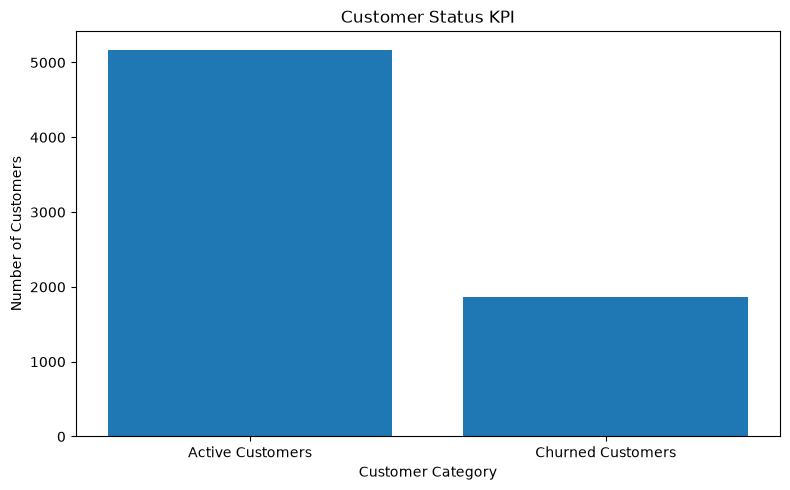

In [6]:
# Customer KPI Visualization

kpi_names = [
    "Active Customers",
    "Churned Customers"
]

kpi_values = [
    active_customers,
    churned_customers
]

plt.figure(figsize=(8, 5))

plt.bar(kpi_names, kpi_values)

plt.title("Customer Status KPI")
plt.xlabel("Customer Category")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig("day39_customer_kpi.png", dpi=300)

plt.show()

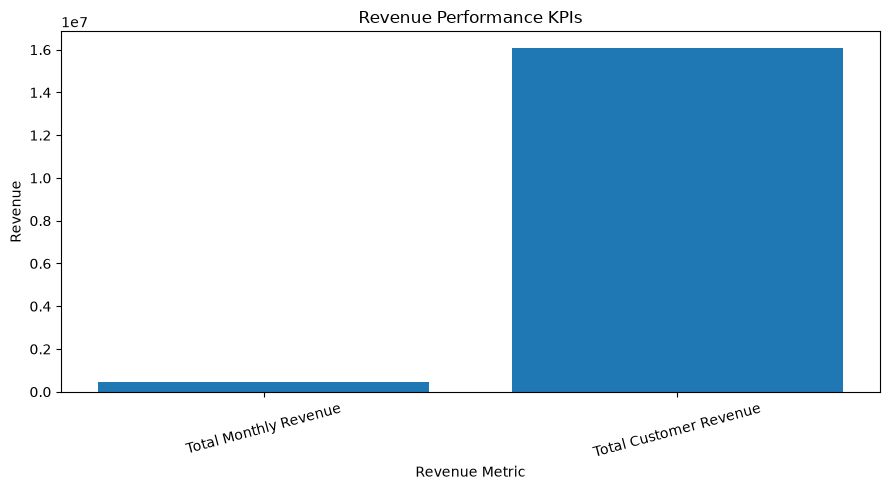

In [7]:
# Revenue KPI Visualization

revenue_names = [
    "Total Monthly Revenue",
    "Total Customer Revenue"
]

revenue_values = [
    total_monthly_revenue,
    total_customer_revenue
]

plt.figure(figsize=(9, 5))

plt.bar(revenue_names, revenue_values)

plt.title("Revenue Performance KPIs")
plt.xlabel("Revenue Metric")
plt.ylabel("Revenue")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig("day39_revenue_kpi.png", dpi=300)

plt.show()

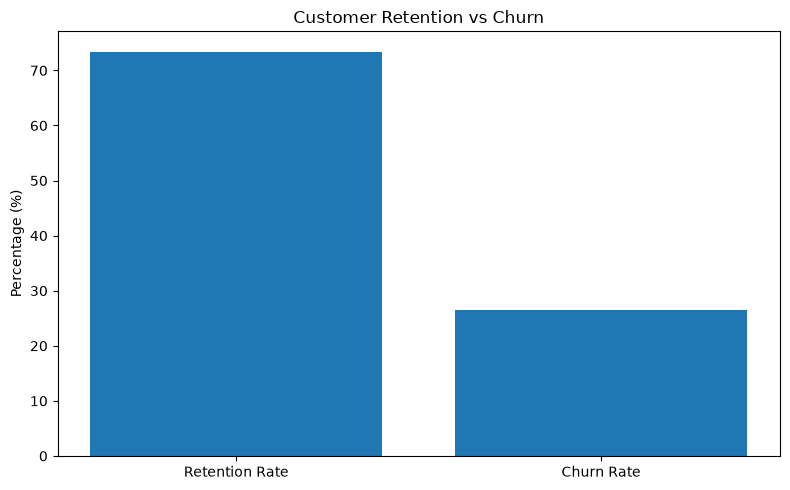

In [8]:
# Retention vs Churn

labels = ["Retention Rate", "Churn Rate"]
values = [retention_rate, churn_rate]

plt.figure(figsize=(8, 5))

plt.bar(labels, values)

plt.title("Customer Retention vs Churn")
plt.ylabel("Percentage (%)")

plt.tight_layout()

plt.savefig("day39_retention_churn_kpi.png", dpi=300)

plt.show()

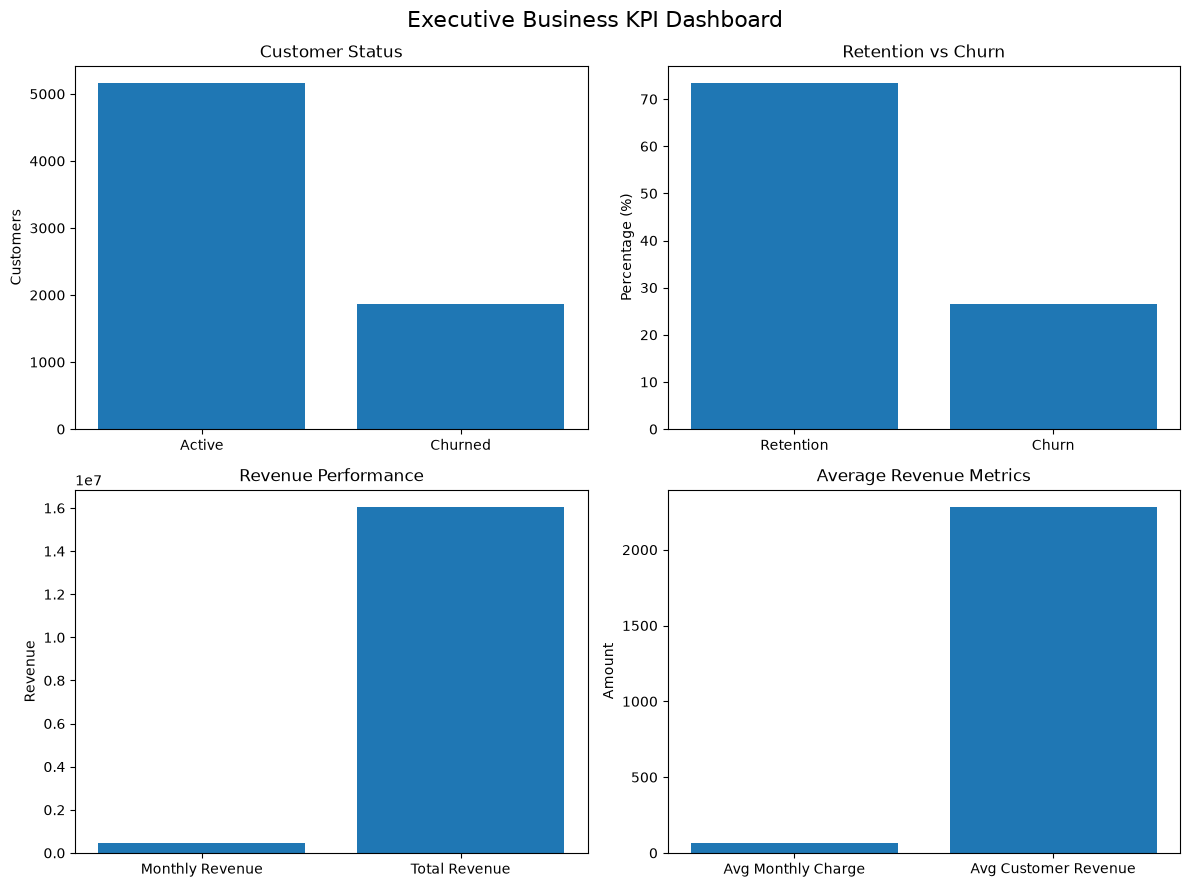

In [9]:
# Day 39 Executive KPI Dashboard

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Customer Status
axes[0, 0].bar(
    ["Active", "Churned"],
    [active_customers, churned_customers]
)
axes[0, 0].set_title("Customer Status")
axes[0, 0].set_ylabel("Customers")

# 2. Retention vs Churn
axes[0, 1].bar(
    ["Retention", "Churn"],
    [retention_rate, churn_rate]
)
axes[0, 1].set_title("Retention vs Churn")
axes[0, 1].set_ylabel("Percentage (%)")

# 3. Revenue
axes[1, 0].bar(
    ["Monthly Revenue", "Total Revenue"],
    [total_monthly_revenue, total_customer_revenue]
)
axes[1, 0].set_title("Revenue Performance")
axes[1, 0].set_ylabel("Revenue")

# 4. Average Metrics
axes[1, 1].bar(
    ["Avg Monthly Charge", "Avg Customer Revenue"],
    [average_monthly_revenue, average_customer_revenue]
)
axes[1, 1].set_title("Average Revenue Metrics")
axes[1, 1].set_ylabel("Amount")

plt.suptitle(
    "Executive Business KPI Dashboard",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "day39_executive_kpi_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
# Save KPI report

kpi_summary.to_csv(
    "day39_business_kpi_report.csv",
    index=False
)

print("KPI report saved successfully!")

KPI report saved successfully!


In [11]:
# KPI Performance Trends by Customer Tenure

tenure_kpi = data.groupby("tenure").agg(
    CustomerCount=("customerID", "count"),
    AverageMonthlyCharge=("MonthlyCharges", "mean"),
    ChurnRate=("ChurnFlag", "mean")
).reset_index()

tenure_kpi["ChurnRate"] = tenure_kpi["ChurnRate"] * 100

tenure_kpi.head()

,tenure,CustomerCount,AverageMonthlyCharge,ChurnRate
0,1,613,50.485808,61.990212
1,2,238,57.206303,51.680672
2,3,200,58.015000,47.000000
3,4,176,57.432670,47.159091
4,5,133,61.003759,48.120301


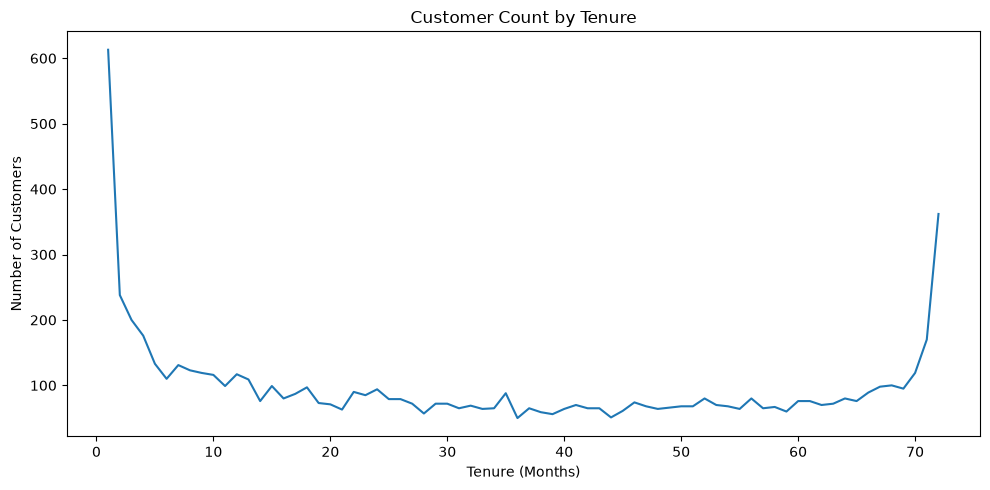

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    tenure_kpi["tenure"],
    tenure_kpi["CustomerCount"]
)

plt.title("Customer Count by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "day39_customer_tenure_trend.png",
    dpi=300
)

plt.show()

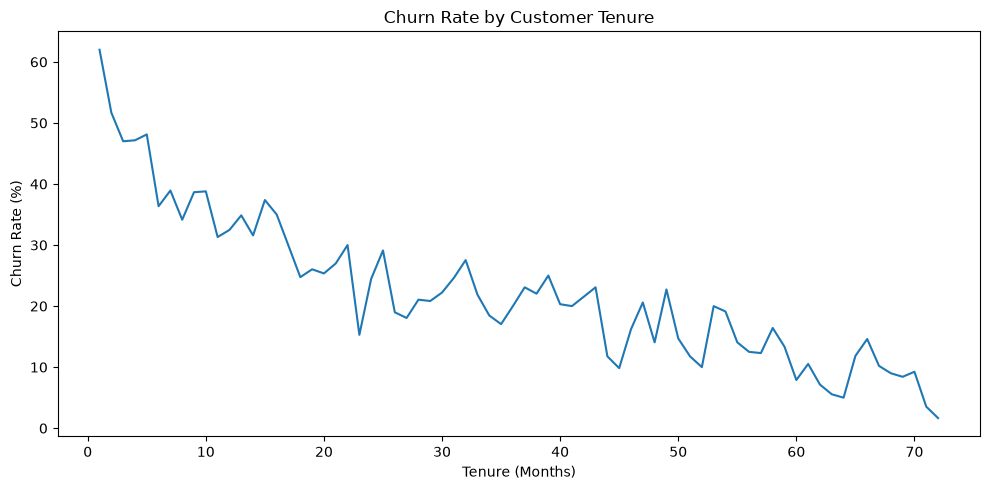

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    tenure_kpi["tenure"],
    tenure_kpi["ChurnRate"]
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    "day39_churn_tenure_trend.png",
    dpi=300
)

plt.show()

In [14]:
# Executive Business Insights

highest_churn_tenure = tenure_kpi.loc[
    tenure_kpi["ChurnRate"].idxmax()
]

lowest_churn_tenure = tenure_kpi.loc[
    tenure_kpi["ChurnRate"].idxmin()
]

insights = f"""
DAY 39 — BUSINESS KPI ANALYTICS REPORT
======================================

CUSTOMER PERFORMANCE
--------------------
Total Customers: {total_customers}
Active Customers: {active_customers}
Churned Customers: {churned_customers}
Retention Rate: {retention_rate:.2f}%
Churn Rate: {churn_rate:.2f}%
Average Tenure: {average_tenure:.2f} months

REVENUE PERFORMANCE
-------------------
Total Monthly Revenue: {total_monthly_revenue:.2f}
Average Monthly Charge: {average_monthly_revenue:.2f}
Total Customer Revenue: {total_customer_revenue:.2f}
Average Customer Revenue: {average_customer_revenue:.2f}

TENURE KPI ANALYSIS
-------------------
Highest observed churn rate occurs at:
{int(highest_churn_tenure['tenure'])} months
Churn Rate: {highest_churn_tenure['ChurnRate']:.2f}%

Lowest observed churn rate occurs at:
{int(lowest_churn_tenure['tenure'])} months
Churn Rate: {lowest_churn_tenure['ChurnRate']:.2f}%

EXECUTIVE INSIGHTS
------------------
1. Customer retention and churn should be monitored as core business KPIs.
2. Revenue KPIs help track the financial contribution of the customer base.
3. Tenure-based churn analysis can help identify periods where retention
   monitoring may need additional attention.
4. Customer and revenue KPIs should be reviewed together rather than
   independently.
5. KPI dashboards can support regular business performance monitoring.
"""

print(insights)

with open(
    "day39_executive_business_insights.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(insights)

print("\nExecutive insights report saved successfully!")


DAY 39 — BUSINESS KPI ANALYTICS REPORT

CUSTOMER PERFORMANCE
--------------------
Total Customers: 7032
Active Customers: 5163
Churned Customers: 1869
Retention Rate: 73.42%
Churn Rate: 26.58%
Average Tenure: 32.42 months

REVENUE PERFORMANCE
-------------------
Total Monthly Revenue: 455661.00
Average Monthly Charge: 64.80
Total Customer Revenue: 16056168.70
Average Customer Revenue: 2283.30

TENURE KPI ANALYSIS
-------------------
Highest observed churn rate occurs at:
1 months
Churn Rate: 61.99%

Lowest observed churn rate occurs at:
72 months
Churn Rate: 1.66%

EXECUTIVE INSIGHTS
------------------
1. Customer retention and churn should be monitored as core business KPIs.
2. Revenue KPIs help track the financial contribution of the customer base.
3. Tenure-based churn analysis can help identify periods where retention
   monitoring may need additional attention.
4. Customer and revenue KPIs should be reviewed together rather than
   independently.
5. KPI dashboards can support reg